<a href="https://colab.research.google.com/github/sanjanascorner/PyTorch-and-DeepLearning/blob/main/YOLOX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn, tensor
import numpy as np
import math
from math import sqrt
import os
import json
from random import randint, uniform
import skimage.io as io
from copy import deepcopy
from PIL import Image

In [ ]:
cpu=torch.device('cpu')
gpu=torch.device('cuda:0')

In [ ]:
class conv(nn.Module):
  #A single layer of convolution used in Darknet53
   def __init__(self,in_channels,out_channels,kernel_size=3,stride=1,padding=1):
       super(conv,self).__init__()
       self.block=nn.Sequential(
         nn.Conv2d(in_channels,out_channels,kernel_size,stride=stride,padding=padding,bias=False),
         nn.BatchNorm2d(out_channels),
         nn.LeakyReLU(0.1)
     )
   def forward(self,X):
       return self.block(X)
class residual(nn.Module):
      def __init__(self,in_channels):
          super(residual,self).__init__()
          self.block=nn.Sequential(
              conv(in_channels,in_channels//2,kernel_size=1,padding=0),
              conv(in_channels//2,in_channels,kernel_size=3)

          )
      def forward(self,X):
          return self.block(X)+X



In [ ]:
class Darknet53(nn.Module):
    def __init__(self, device, numClasses, inchannelsize=3):
        super(Darknet53, self).__init__()

        def res_stack(ch, n):
            return nn.Sequential(*[residual(ch) for _ in range(n)])

        self.block1 = nn.Sequential(conv(inchannelsize, 32), conv(32, 64, stride=2))
        self.res1 = res_stack(64, 1)
        self.block2 = nn.Sequential(conv(64, 128, stride=2))
        self.res2 = res_stack(128, 2)
        self.block3 = nn.Sequential(conv(128, 256, stride=2))
        self.res3 = res_stack(256, 8)
        self.block4 = nn.Sequential(conv(256, 512, stride=2))
        self.res4 = res_stack(512, 8)
        self.block5 = nn.Sequential(conv(512, 1024, stride=2))
        self.res5 = res_stack(1024, 4)

        for i, ch in enumerate([1024, 512, 256], start=1):
            setattr(self, f"head{i}_1x1", nn.Sequential(conv(ch, 256, kernel_size=1, padding=0)))
            setattr(self, f"head{i}_cls", nn.Sequential(
                conv(256, 256), conv(256, 256),
                nn.Conv2d(256, numClasses, kernel_size=1, padding=0, bias=False)))
            setattr(self, f"head{i}_reg_base", nn.Sequential(conv(256, 256), conv(256, 256)))
            setattr(self, f"head{i}_reg", nn.Sequential(nn.Conv2d(256, 4, kernel_size=1, padding=0, bias=False)))
            setattr(self, f"head{i}_IOU", nn.Sequential(nn.Conv2d(256, 1, kernel_size=1, padding=0, bias=False)))

        self.to(device)

    def forward(self, X):
        X = self.block1(X)
        X = self.res1(X)
        X = self.block2(X)
        X = self.res2(X)
        X = self.block3(X)
        X = self.res3(X)
        p3 = X
        X = self.block4(X)
        X = self.res4(X)
        p2 = X
        X = self.block5(X)
        X = self.res5(X)
        p1 = X
        outs = []
        for i, feat in enumerate([p1, p2, p3], start=1):
            feat = getattr(self, f"head{i}_1x1")(feat)
            cls = getattr(self, f"head{i}_cls")(feat)
            base = getattr(self, f"head{i}_reg_base")(feat)
            reg = getattr(self, f"head{i}_reg")(base)
            obj = getattr(self, f"head{i}_IOU")(base)
            outs.append([cls, reg, obj])
        return outs[0], outs[1], outs[2]

In [ ]:
class LossFunctions():
    def __init__(self, FL_gamma, FL_alpha):
        self.FL_gamma = FL_gamma
        self.FL_alpha = FL_alpha

    def FocalLoss(self, z, y):
        p = torch.sigmoid(z.float())
        y = torch.as_tensor(y, device=p.device)
        p_t = torch.where(y == 1, p, 1 - p)
        p_t = torch.clamp(p_t, min=1e-6)
        return -self.FL_alpha * ((1 - p_t) ** self.FL_gamma) * torch.log(p_t)

    def BinaryCrossEntropy(self, y_hat, y):
        return torch.nn.BCEWithLogitsLoss(reduction='sum')(y_hat, y)

    def CrossEntropy(self, y_hat, y):
        y_hat = torch.clamp(y_hat, 1e-6, 1 - 1e-6)
        return -torch.mean(y * torch.log(y_hat))

    def GIoU(self, pred, GT):
        if pred.shape[0] == 0 or GT.shape[0] == 0:
            empty = torch.zeros(0, device=pred.device)
            return empty, empty
        pred = pred.float()
        GT = GT.float().to(pred.device)
        x_1_p = torch.minimum(pred[:, 0], pred[:, 0] + pred[:, 2])
        x_2_p = torch.maximum(pred[:, 0], pred[:, 0] + pred[:, 2])
        y_1_p = torch.minimum(pred[:, 1], pred[:, 1] + pred[:, 3])
        y_2_p = torch.maximum(pred[:, 1], pred[:, 1] + pred[:, 3])
        x_1_g = GT[:, 0]
        x_2_g = GT[:, 0] + GT[:, 2]
        y_1_g = GT[:, 1]
        y_2_g = GT[:, 1] + GT[:, 3]
        A_g = (x_2_g - x_1_g) * (y_2_g - y_1_g)
        A_p = (x_2_p - x_1_p) * (y_2_p - y_1_p)
        x_1_I = torch.maximum(x_1_p, x_1_g)
        x_2_I = torch.minimum(x_2_p, x_2_g)
        y_1_I = torch.maximum(y_1_p, y_1_g)
        y_2_I = torch.minimum(y_2_p, y_2_g)
        I = torch.clamp(x_2_I - x_1_I, min=0) * torch.clamp(y_2_I - y_1_I, min=0)
        x_1_c = torch.minimum(x_1_p, x_1_g)
        x_2_c = torch.maximum(x_2_p, x_2_g)
        y_1_c = torch.minimum(y_1_p, y_1_g)
        y_2_c = torch.maximum(y_2_p, y_2_g)
        A_c = (x_2_c - x_1_c) * (y_2_c - y_1_c)
        U = A_p + A_g - I
        IoU = torch.where(U > 0, I / U.clamp(min=1e-9), torch.zeros_like(U))
        GIoU = IoU - (A_c - U) / A_c.clamp(min=1e-9)
        GIoU = torch.clamp(GIoU, -1.0, 1.0)
        return 1 - GIoU, GIoU

    GIOU = GIoU

    def IOU(self, pred, GT):
        if len(pred.shape) > len(GT.shape):
            GT = torch.unsqueeze(GT, dim=0)
        elif len(pred.shape) < len(GT.shape):
            pred = torch.unsqueeze(pred, dim=0)
        xA = torch.maximum(pred[:, 0], GT[:, 0])
        yA = torch.maximum(pred[:, 1], GT[:, 1])
        xB = torch.minimum(pred[:, 0] + pred[:, 2], GT[:, 0] + GT[:, 2])
        yB = torch.minimum(pred[:, 1] + pred[:, 3], GT[:, 1] + GT[:, 3])
        intersectionArea = torch.clamp(xB - xA + 1, min=0) * torch.clamp(yB - yA + 1, min=0)
        areaA = (pred[:, 2] + 1) * (pred[:, 3] + 1)
        areaB = (GT[:, 2] + 1) * (GT[:, 3] + 1)
        union = areaA + areaB - intersectionArea
        IoU = torch.where(union > 0, intersectionArea / union.clamp(min=1e-9), torch.zeros_like(union))
        IoU_loss = 1 - IoU
        return IoU_loss, IoU

In [ ]:
def convertNumpy(item):
    if isinstance(item, np.ndarray):
        return item
    if isinstance(item, torch.Tensor):
        return item.cpu().detach().numpy()
    return np.array(item)


def centerPrior(A, G_box, r, extraCost):
    center = (G_box[0] + (G_box[2] // 2), G_box[1] + (G_box[3] // 2))
    diff = A - center
    dist = np.sqrt(np.sum(diff ** 2, axis=-1))
    idx_neg = np.where(dist > r ** 2)
    c_cp = np.zeros(A.shape[0])
    c_cp[idx_neg] = extraCost
    return c_cp


def SimOTA(G_reg, G_cls, A, P_cls, P_reg, q, r, extraCost, Lambda, LossFuncts):
    G_reg = convertNumpy(G_reg)
    G_cls = convertNumpy(G_cls)
    A = convertNumpy(A)
    P_reg = convertNumpy(P_reg)
    P_cls = convertNumpy(P_cls)

    m = len(G_reg)
    n = A.shape[0]

    s_i = np.ones(m + 1, dtype=np.int32)
    k_sum = 0
    for i in range(0, m):
        gt = G_reg[i]
        xA = np.maximum(gt[0], P_reg[:, 0])
        yA = np.maximum(gt[1], P_reg[:, 1])
        xB = np.minimum(gt[0] + gt[2], P_reg[:, 0] + P_reg[:, 2])
        yB = np.minimum(gt[1] + gt[3], P_reg[:, 1] + P_reg[:, 3])
        intersectionArea = np.maximum(0, xB - xA + 1) * np.maximum(0, yB - yA + 1)
        areaA = (gt[2] + 1) * (gt[3] + 1)
        areaB = (P_reg[:, 2] + 1) * (P_reg[:, 3] + 1)
        union = areaA + areaB - intersectionArea
        IoU = intersectionArea / union
        IoU[union == 0] = 0
        IoU[np.isnan(IoU)] = 0
        k = np.sort(IoU)[-q:].sum()
        k_sum += k
        s_i[i] = max(1, int(round(k)))
    s_i[-1] = n - round(k_sum)

    c_cls = np.zeros((m, n))
    c_reg = np.zeros((m, n))
    c_cp = np.zeros((m, n))

    preds_cls = torch.argmax(torch.tensor(P_cls), dim=-1)

    for i in range(0, m):
        loss_cls = LossFuncts.FocalLoss(preds_cls, torch.tensor(G_cls[i].astype(np.int32)))
        loss_giou = LossFuncts.GIoU(torch.tensor(P_reg), torch.tensor(G_reg[i:i + 1].astype(np.int32)))[0]
        loss_cp = centerPrior(A, G_reg[i], r, extraCost)
        c_cls[i] = loss_cls.cpu().numpy()
        c_reg[i] = loss_giou.cpu().numpy()
        c_cp[i] = loss_cp

    c_bg = LossFuncts.FocalLoss(preds_cls, torch.zeros(preds_cls.shape)).cpu().detach().numpy()
    c_bg = np.array([c_bg])

    c_fg = c_cls + Lambda * c_reg + c_cp
    cost = np.concatenate((c_fg, c_bg))

    pos_idx = []
    for i in range(0, m):
        k = s_i[i]
        cost_gt = cost[i]
        idx = np.argsort(cost_gt)[:k]
        pos_idx.append(idx)

    return pos_idx

In [ ]:

def resize(img, anns, size):
    img = Image.fromarray(img)
    prop_w = size[0]/img.width
    prop_h = size[1]/img.height
    new_w = round(img.width*prop_w)
    new_h = round(img.height*prop_h)
    img = img.resize((new_w, new_h))
    img = np.array(img, dtype=np.uint8).transpose(2,0,1)
    for a in range(0, len(anns["bbox"])):
        anns["bbox"][a][0] *= prop_w
        anns["bbox"][a][2] *= prop_w
        anns["bbox"][a][1] *= prop_h
        anns["bbox"][a][3] *= prop_h
    return img, anns

def Mosaic(imgs, anns, size):
    for i in range(0, len(imgs)):
        if imgs[i].shape[-1] != 3:
            imgs[i] = imgs[i].transpose(1, 2, 0)
    for img in range(0, len(imgs)):
        if imgs[img].shape[0] != size[0] or imgs[img].shape[1] != size[1]:
            imgs[img], anns[img] = resize(imgs[img], anns[img], size)
    img_combined = torch.zeros((3, size[0]*2, size[1]*2), requires_grad=False, dtype=torch.int16)
    img_combined[:, :size[0], :size[1]] = torch.tensor(imgs[0], dtype=torch.int16, requires_grad=False)
    img_combined[:, :size[0], size[1]:] = torch.tensor(imgs[1], dtype=torch.int16, requires_grad=False)
    img_combined[:, size[0]:, :size[1]] = torch.tensor(imgs[2], dtype=torch.int16, requires_grad=False)
    img_combined[:, size[0]:, size[1]:] = torch.tensor(imgs[3], dtype=torch.int16, requires_grad=False)
    ann_bbox = []
    ann_cls = []
    ann_bbox += anns[0]["bbox"]
    ann_cls += anns[0]["cls"]
    ann_cls += anns[1]["cls"]
    for a in range(0, len(anns[1]["bbox"])):
        anns[1]["bbox"][a][0] += size[0]
        ann_bbox.append(anns[1]["bbox"][a])
    ann_cls += anns[2]["cls"]
    for a in range(0, len(anns[2]["bbox"])):
        anns[2]["bbox"][a][1] += size[1]
        ann_bbox.append(anns[2]["bbox"][a])
    ann_cls += anns[3]["cls"]
    for a in range(0, len(anns[3]["bbox"])):
        anns[3]["bbox"][a][0] += size[0]
        anns[3]["bbox"][a][1] += size[1]
        ann_bbox.append(anns[3]["bbox"][a])
    ann_bbox = np.array(ann_bbox, dtype=np.uint16)
    ann_cls = np.array(ann_cls, dtype=np.uint16)
    topL_x = round(uniform(sqrt(size[0]), size[0]-sqrt(size[0])))
    topL_y = round(uniform(sqrt(size[1]), size[1]-sqrt(size[1])))
    cut_x = (topL_x, topL_x+size[0])
    cut_y = (topL_y, topL_y+size[0])
    cutout = img_combined[:, cut_y[0]:cut_y[1], cut_x[0]:cut_x[1]]
    xA = np.maximum(cut_x[0], ann_bbox[:, 0]).astype(np.int32)
    yA = np.maximum(cut_y[0], ann_bbox[:, 1]).astype(np.int32)
    xB = np.minimum(cut_x[1], ann_bbox[:, 0]+ann_bbox[:, 2]).astype(np.int32)
    yB = np.minimum(cut_y[1], ann_bbox[:, 1]+ann_bbox[:, 3]).astype(np.int32)
    intersectionArea = np.maximum(0, xB - xA + 1) * np.maximum(0, yB - yA + 1)
    ann_bbox = ann_bbox[intersectionArea != 0]
    ann_cls = ann_cls[intersectionArea != 0]
    mask = ann_bbox[:, 0] < cut_x[0]
    ann_bbox[:, 2][mask] -= cut_x[0]-ann_bbox[:, 0][mask]
    ann_bbox[:, 0][mask] = 0
    mask = ann_bbox[:, 1] < cut_y[0]
    ann_bbox[:, 3][mask] -= cut_y[0]-ann_bbox[:, 1][mask]
    ann_bbox[:, 1][mask] = 0
    ann_bbox[:, 0][ann_bbox[:, 0] >= cut_x[0]] -= cut_x[0]
    ann_bbox[:, 1][ann_bbox[:, 1] >= cut_y[0]] -= cut_y[0]
    mask = ann_bbox[:, 2]+ann_bbox[:, 0] > cut_x[1]-cut_x[0]
    ann_bbox[:, 2][mask] = cut_x[1]-cut_x[0]-ann_bbox[:, 0][mask]
    mask = ann_bbox[:, 3]+ann_bbox[:, 1] > cut_y[1]-cut_y[0]
    ann_bbox[:, 3][mask] = cut_y[1]-cut_y[0]-ann_bbox[:, 1][mask]
    pix_cls = torch.zeros(cutout.shape[1:], dtype=torch.int16, requires_grad=False)
    for box_num in range(0, ann_bbox.shape[0]):
        box = ann_bbox[box_num]
        pix_cls[box[0]:box[0]+box[2], box[1]:box[1]+box[3]] = ann_cls[box_num]
    new_anns = {"bbox":ann_bbox.tolist(), "cls":ann_cls, "pix_cls":pix_cls}
    return cutout, new_anns

def mixup(img1, img2, labels1, labels2, finalShape, alpha=1.5):
    if img1.shape[0] != 3:
        img1 = img1.transpose(2, 0, 1)
    if img2.shape[0] != 3:
        img2 = img2.transpose(2, 0, 1)
    width = max(img1.shape[1], img2.shape[1])
    height = max(img1.shape[2], img2.shape[2])
    new_img = np.zeros((3, width, height), dtype=np.float32)
    Lambda = torch.distributions.beta.Beta(alpha, alpha).sample().item()
    img1 = Lambda*img1
    img2 = (1-Lambda)*img2
    new_img[:, 0:img1.shape[1], 0:img1.shape[2]] = img1
    new_img[:, 0:img2.shape[1], 0:img2.shape[2]] += img2
    new_img = new_img.astype(np.int16)
    new_bbox = np.array(labels1["bbox"] + labels2["bbox"], dtype=np.int16)
    new_cls = labels1["cls"] + labels2["cls"]
    new_labels = {"bbox":new_bbox.tolist(), "cls":new_cls}
    new_img, new_labels = resize(new_img.transpose(1,2,0).astype(np.uint8), new_labels, finalShape)
    new_img = torch.tensor(new_img, dtype=torch.int16, requires_grad=False)
    pix_cls = torch.zeros(new_img.shape[1:], dtype=torch.int16, requires_grad=False)
    for box_num in range(0, len(new_bbox)):
        box = new_bbox[box_num]
        pix_cls[box[0]:box[0]+box[2], box[1]:box[1]+box[3]] = new_cls[box_num]
    new_labels["pix_cls"] = pix_cls
    return new_img, new_labels

In [ ]:
def soft_nonmaxSupression(B, S, C, score_thresh, IoU_thresh, IoU_function):
    D = []
    scores = []
    classes = []
    for img in range(0, len(B)):
        b = np.array(B[img])
        s_static = np.array(S[img])
        s = S[img]
        c = C[img]
        D_img = []
        scores_img = []
        classes_img = []
        while b.shape[0] > 0:
            m = np.argmax(s)
            M = b[m]
            D_img.append(M)
            scores_img.append(s_static[m])
            classes_img.append(c[m])
            b = np.delete(b, m, axis=0)
            s_static = np.delete(s_static, m, axis=0)
            s = np.delete(s, m, axis=0)
            c = np.delete(c, m, axis=0)
            if b.shape[0] == 0:
                break
            mean_scores = np.mean(s)
            idx_to_remove = []
            _, IoU = IoU_function(tensor(M), tensor(b))
            IoU = IoU.numpy()
            idxs = np.argwhere(IoU > IoU_thresh)
            if s.shape[-1] == 1 and len(s.shape) > 1:
                s = s.squeeze(-1)
            s = s*np.exp(-((IoU)**2)/mean_scores)
            idx_to_remove = np.squeeze(np.argwhere(s < score_thresh))
            b = np.delete(b, idx_to_remove, axis=0)
            s_static = np.delete(s_static, idx_to_remove, axis=0)
            s = np.delete(s, idx_to_remove, axis=0)
            c = np.delete(c, idx_to_remove, axis=0)
        D.append(D_img)
        scores.append(scores_img)
        classes.append(classes_img)
    return D, scores, classes

In [ ]:
class YOLOX(nn.Module):
    def __init__(self, device, numEpochs, batchSize, warmupEpochs, lr_init, weightDecay, momentum, ImgDim, numCats, FL_alpha, FL_gamma, reg_weight, category_Ids, removal_threshold, score_thresh, IoU_thresh, SimOTA_params=None):
        super(YOLOX, self).__init__()
        self.numEpochs = numEpochs
        self.batchSize = batchSize
        self.warmupEpochs = warmupEpochs
        self.lr_init = lr_init
        self.device_str = device.lower()
        self.ImgDim = ImgDim
        self.numCats = numCats
        self.reg_weight = reg_weight
        self.category_Ids = category_Ids
        self.removal_threshold = removal_threshold
        self.score_thresh = score_thresh
        self.IoU_thresh = IoU_thresh
        self.SimOTA_params = SimOTA_params
        if self.device_str == "fullgpu" or self.device_str == "gpu":
            self.device = gpu
        else:
            self.device = cpu

        self.exp_params = nn.ParameterList([nn.Parameter(torch.tensor(1, device=self.device, dtype=torch.float, requires_grad=True)) for i in range(0, 3)])
        self.strides = [32, 16, 8]
        self.FPNShapes = [ImgDim // self.strides[0], ImgDim // self.strides[1], ImgDim // self.strides[2]]
        self.FPNPos = self.buildPositions()
        self.JSON_Save = {
            "ImgDim": self.ImgDim,
            "numCats": self.numCats,
            "strides": self.strides,
            "category_Ids": self.category_Ids,
            "epoch": 1
        }
        self.epoch = 1
        self.loss_history = []
        if self.device_str == "partgpu":
            self.darknet = Darknet53(gpu, numCats + 1)
        else:
            self.darknet = Darknet53(self.device, numCats + 1)
        self.losses = LossFunctions(FL_gamma, FL_alpha)
        self.optimizer = torch.optim.SGD(self.parameters(), lr=lr_init * batchSize / 64, momentum=momentum, weight_decay=weightDecay)

    def buildPositions(self):
        return [torch.tensor([[(self.strides[i] / 2 + k * self.strides[i], self.strides[i] / 2 + j * self.strides[i]) for k in range(0, self.FPNShapes[i])] for j in range(0, self.FPNShapes[i])], device=self.device, dtype=torch.long) for i in range(0, len(self.strides))]

    def forward(self, X):
        if type(X) != torch.Tensor:
            X = torch.tensor(X, dtype=torch.float, device=self.device, requires_grad=False)
        if X.dtype != torch.float32:
            X = X.float()
        FPN1, FPN2, FPN3 = self.darknet(X)
        return [FPN1[0], FPN2[0], FPN3[0]], [FPN1[1], FPN2[1], FPN3[1]], [FPN1[2], FPN2[2], FPN3[2]]

    def regDecode(self, regs, p):
        pos = self.FPNPos[p].reshape(-1, 2).to(regs.device)
        xy = regs[..., :2] + pos
        wh = torch.clamp(self.exp_params[p] * regs[..., 2:], 0, math.log(self.ImgDim // 2))
        wh = torch.exp(wh) * self.strides[p]
        return torch.cat([xy, wh], dim=-1)

    def flatten_outputs(self, outs):
        cls_l, reg_l, obj_l = outs
        cls_all, reg_all, obj_all = [], [], []
        for p in range(0, 3):
            B = cls_l[p].shape[0]
            cls_all.append(cls_l[p].permute(0, 2, 3, 1).reshape(B, -1, cls_l[p].shape[1]))
            reg = reg_l[p].permute(0, 2, 3, 1).reshape(B, -1, 4)
            reg_all.append(self.regDecode(reg, p))
            obj_all.append(obj_l[p].permute(0, 2, 3, 1).reshape(B, -1, 1))
        return torch.cat(cls_all, dim=1), torch.cat(reg_all, dim=1), torch.cat(obj_all, dim=1)
    def batches(self, X, y):
        if isinstance(X, DataLoader):
            for xb, ys in X:
                yield xb, ys
        else:
            perm = torch.randperm(X.shape[0]).tolist()
            for s in range(0, len(perm), self.batchSize):
                ids = perm[s:s + self.batchSize]
                yield X[ids], [y[i] for i in ids]

    def set_lr(self, epoch):
        base = self.lr_init * self.batchSize / 64
        if self.warmupEpochs > 0 and epoch <= self.warmupEpochs:
            lr = base * epoch / self.warmupEpochs
        else:
            span = max(1, self.numEpochs - self.warmupEpochs)
            progress = min(1.0, (epoch - self.warmupEpochs - 1) / span)
            lr = base * 0.5 * (1 + math.cos(math.pi * progress))
        for g in self.optimizer.param_groups:
            g["lr"] = lr
        return lr

    def batch_loss(self, xb, ys, anchors):
        q, r, extraCost, Lambda = self.SimOTA_params
        dev = xb.device
        cls_all, reg_all, obj_all = self.flatten_outputs(self.forward(xb))
        C = cls_all.shape[-1]
        n = cls_all.shape[1]
        reg_loss = torch.zeros((), device=dev)
        cls_loss = torch.zeros((), device=dev)
        obj_loss = torch.zeros((), device=dev)
        num_fg = 0
        for b in range(0, xb.shape[0]):
            boxes = np.array(ys[b]["bbox"], dtype=np.float32).reshape(-1, 4)
            classes = np.array(ys[b]["cls"], dtype=np.int64).reshape(-1)
            obj_target = torch.zeros(n, 1, device=dev)
            if len(boxes) > 0:
                pos_lists = SimOTA(boxes, classes, anchors, cls_all[b].detach().cpu().numpy(), reg_all[b].detach().cpu().numpy(), q, r, extraCost, Lambda, self.losses)
                gt_t = torch.tensor(boxes, device=dev)
                cls_t = torch.tensor(classes, device=dev)
                reg_det = reg_all[b].detach()
                giou_mat = torch.stack([self.losses.GIoU(reg_det, gt_t[i:i + 1])[1] for i in range(0, len(boxes))])
                claim = torch.zeros_like(giou_mat, dtype=torch.bool)
                for i, idx in enumerate(pos_lists):
                    claim[i, torch.as_tensor(idx, dtype=torch.long, device=dev)] = True
                masked = torch.where(claim, giou_mat, torch.full_like(giou_mat, -2.0))
                best_gt = masked.argmax(dim=0)
                pos_idx = torch.nonzero(claim.any(dim=0)).squeeze(1)
                if pos_idx.numel() > 0:
                    matched = best_gt[pos_idx]
                    giou_pos = self.losses.GIoU(reg_all[b][pos_idx], gt_t[matched])[1]
                    reg_loss = reg_loss + (1 - giou_pos).sum()
                    onehot = F.one_hot(cls_t[matched], num_classes=C).float()
                    cls_loss = cls_loss + self.losses.FocalLoss(cls_all[b][pos_idx], onehot).sum()
                    obj_target[pos_idx] = 1
                    num_fg += int(pos_idx.numel())
            obj_loss = obj_loss + self.losses.BinaryCrossEntropy(obj_all[b], obj_target)
        norm = max(num_fg, 1)
        total = (self.reg_weight * reg_loss + cls_loss + obj_loss) / norm
        return total, (reg_loss.item() / norm, cls_loss.item() / norm, obj_loss.item() / norm, num_fg)

    def train_model(self, X, y, dataAug_params=None, augment_per=0.0, saveParams=None):
        self.train()
        if saveParams is None:
            saveParams = ["./models", "modelParams", "model", 10, False, False]
        saveDir, paramSaveName, saveName, saveSteps, saveOnBest, overwrite = saveParams
        anchors = np.concatenate([p.reshape(-1, 2).cpu().numpy() for p in self.FPNPos]).astype(np.float32)
        bestLoss = float("inf")
        for self.epoch in range(self.epoch, self.numEpochs + 1):
            lr = self.set_lr(self.epoch)
            epoch_loss = 0.0
            parts = np.zeros(4)
            batches = 0
            for xb, ys in self.batches(X, y):
                xb = xb.float().to(self.device)
                self.optimizer.zero_grad()
                loss, p = self.batch_loss(xb, ys, anchors)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), 10.0)
                self.optimizer.step()
                epoch_loss += loss.item()
                parts += np.array(p, dtype=np.float64)
                batches += 1
            epoch_loss /= max(batches, 1)
            parts /= max(batches, 1)
            self.loss_history.append(epoch_loss)
            print(f"epoch {self.epoch}/{self.numEpochs}  lr {lr:.5f}  loss {epoch_loss:.4f}  reg {parts[0]:.3f}  cls {parts[1]:.3f}  obj {parts[2]:.3f}  positives/batch {parts[3]:.1f}")
            if self.epoch % saveSteps == 0:
                if (not saveOnBest) or epoch_loss < bestLoss:
                    self.saveModel(saveDir, paramSaveName, saveName, overwrite)
            bestLoss = min(bestLoss, epoch_loss)
        return self.loss_history

    def saveModel(self, saveDir, paramSaveName, saveName, overwrite):
        os.makedirs(saveDir, exist_ok=True)
        modelSaveName = saveName
        paramName = paramSaveName
        if not overwrite:
            modelSaveName = f"{saveName} - {self.epoch}"
            paramName = f"{paramSaveName} - {self.epoch}"
        self.JSON_Save["epoch"] = self.epoch + 1
        torch.save(self.state_dict(), os.path.join(saveDir, f"{modelSaveName}.pkl"))
        with open(os.path.join(saveDir, f"{paramName}.json"), "w", encoding="utf-8") as f:
            json.dump(self.JSON_Save, f, ensure_ascii=False)

    def loadModel(self, loadDir, loadName, paramLoadName):
        modelFileName = os.path.join(loadDir, loadName)
        paramFileName = os.path.join(loadDir, paramLoadName)
        assert os.path.isdir(loadDir), f"Load directory {loadDir} does not exist."
        assert os.path.isfile(modelFileName), f"Load file {modelFileName} does not exist."
        assert os.path.isfile(paramFileName), f"Load file {paramFileName} does not exist."
        self.load_state_dict(torch.load(modelFileName, map_location=self.device))
        with open(paramFileName, "r", encoding="utf-8") as f:
            data = json.load(f)
        self.ImgDim = data["ImgDim"]
        self.numCats = data["numCats"]
        self.strides = data["strides"]
        self.category_Ids = data["category_Ids"]
        self.epoch = data["epoch"]
        self.JSON_Save = data
        self.FPNShapes = [self.ImgDim // self.strides[0], self.ImgDim // self.strides[1], self.ImgDim // self.strides[2]]
        self.FPNPos = self.buildPositions()

    @torch.no_grad()
    def predict(self, X, batchSize=0):
        self.eval()
        if type(X) != torch.Tensor:
            X = torch.tensor(np.array(X))
        if X.shape[1] > X.shape[3]:
            X = X.permute(0, 3, 1, 2)
        X = X.float().to(self.device)
        batches = torch.split(X, batchSize) if batchSize != 0 else [X]
        cls_f = [[] for _ in range(len(X))]
        reg_f = [[] for _ in range(len(X))]
        obj_f = [[] for _ in range(len(X))]
        offset = 0
        for xb in batches:
            cls_all, reg_all, obj_all = self.flatten_outputs(self.forward(xb))
            cls_ids = torch.sigmoid(cls_all).argmax(dim=-1).cpu().numpy()
            reg_np = reg_all.cpu().numpy().copy()
            obj_np = torch.sigmoid(obj_all).cpu().numpy()
            dim = X.shape[-1]
            reg_np[:, :, :2] = np.clip(reg_np[:, :, :2], 0, dim)
            reg_np[:, :, 2:] = np.clip(reg_np[:, :, 2:], 0, np.inf)
            reg_np[:, :, 2] = np.where(reg_np[:, :, 0] + reg_np[:, :, 2] > dim, dim - reg_np[:, :, 0], reg_np[:, :, 2])
            reg_np[:, :, 3] = np.where(reg_np[:, :, 1] + reg_np[:, :, 3] > dim, dim - reg_np[:, :, 1], reg_np[:, :, 3])
            for el in range(0, xb.shape[0]):
                mask = obj_np[el, :, 0] > self.removal_threshold
                for c, rg, ob in zip(cls_ids[el][mask], reg_np[el][mask], obj_np[el][mask]):
                    cls_f[offset + el].append(c)
                    reg_f[offset + el].append(rg)
                    obj_f[offset + el].append(ob)
            offset += xb.shape[0]
        boxes, scores, classes = soft_nonmaxSupression(reg_f, obj_f, cls_f, self.score_thresh, self.IoU_thresh, self.losses.IOU)
        return classes, boxes, scores

In [ ]:
!pip install -q pycocotools scikit-image
!mkdir -p /content/coco/images
!wget -q http://images.cocodataset.org/zips/val2017.zip
!unzip -q -o val2017.zip -d /content/coco/images
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q -o annotations_trainval2017.zip -d /content/coco

In [ ]:
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
import random


In [ ]:
dataDir = "/content/coco"
dataType = "val2017"
numToLoad = 150
ImgDim = 256
categories = ["cat", "dog"]
coco = COCO(f"{dataDir}/annotations/instances_{dataType}.json")
category_Ids = {}
seq_category_Ids = {}
for i, name in enumerate(categories):
    category_Ids[name] = coco.getCatIds(catNms=[name])[0]
    seq_category_Ids[name] = i + 1
seq_category_Ids["Background"] = 0
numCats = len(categories)
random.seed(0)
per_class = numToLoad // numCats
seen = set()
img_data = []

loading annotations into memory...
Done (t=0.54s)
creating index...
index created!


In [ ]:
class CocoSubset(Dataset):
    def __init__(self, coco, img_data, category_Ids, img_dir, ImgDim):
        self.coco = coco
        self.img_data = img_data
        self.cat_list = list(category_Ids.values())
        self.img_dir = img_dir
        self.ImgDim = ImgDim

    def __len__(self):
        return len(self.img_data)

    def __getitem__(self, i):
        info = self.img_data[i]
        img = Image.open(os.path.join(self.img_dir, info["file_name"])).convert("RGB")
        scale = self.ImgDim / max(img.height, img.width)
        new_h = round(img.height * scale)
        new_w = round(img.width * scale)
        img = np.array(img.resize((new_w, new_h)))
        pad_top = (self.ImgDim - new_h) - (self.ImgDim - new_h) // 2
        pad_left = (self.ImgDim - new_w) - (self.ImgDim - new_w) // 2
        img = np.pad(img, ((pad_top, (self.ImgDim - new_h)// 2), (pad_left, (self.ImgDim - new_w) // 2), (0, 0)), mode="constant")

        boxes = []
        classes = []
        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=info["id"], iscrowd=False))
        for a in anns:
            if a["category_id"] not in self.cat_list:
                continue
            x0, y0, w, h = [v * scale for v in a["bbox"]]
            if w < 1 or h < 1:
                continue
            boxes.append([x0 + pad_left, y0 + pad_top, w, h])
            classes.append(self.cat_list.index(a["category_id"]) + 1)

        return torch.from_numpy(img).permute(2, 0, 1).contiguous(), {"bbox": boxes, "cls": classes}


def collate(batch):
    imgs = torch.stack([b[0] for b in batch])
    targets = [b[1] for b in batch]
    return imgs, targets

img_ids = set()
for cat_name, cat_id in category_Ids.items():
    ids = coco.getImgIds(catIds=[cat_id])
    img_ids.update(ids)
img_ids_list = list(img_ids)
random.shuffle(img_ids_list)
selected_ids = img_ids_list[:numToLoad]
img_data = coco.loadImgs(selected_ids)

dataset = CocoSubset(coco, img_data, category_Ids, f"{dataDir}/images/{dataType}", ImgDim)
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2, collate_fn=collate)

In [ ]:
import torch.nn.functional as F

device = "fullGPU" if torch.cuda.is_available() else "cpu"
numEpochs = 60
batchSize = 8
warmupEpochs = 2
alpha = 0.04
weightDecay = 0.0005
momentum = 0.9
q, r, extraCost, SimOta_lambda = 20, 5, 100000.0, 3.0
FL_alpha, FL_gamma, reg_weight = 4.0, 2.0, 5.0
removal_threshold, score_thresh, IoU_thresh = 0.5, 0.5, 0.1
saveParams = ["/content/models", "modelParams", "model", 5, False, False]

model = YOLOX(device, numEpochs, batchSize, warmupEpochs, alpha, weightDecay, momentum, ImgDim, numCats, FL_alpha, FL_gamma, reg_weight, seq_category_Ids, removal_threshold, score_thresh, IoU_thresh, [q, r, extraCost, SimOta_lambda])
history = model.train_model(loader, None, None, 0.0, saveParams)

epoch 1/60  lr 0.00250  loss 118.2682  reg 0.920  cls 2.895  obj 110.775  positives/batch 20.4
epoch 2/60  lr 0.00500  loss 14.7068  reg 0.921  cls 2.325  obj 7.776  positives/batch 21.3
epoch 3/60  lr 0.00500  loss 12.6848  reg 0.911  cls 1.995  obj 6.135  positives/batch 22.2
epoch 4/60  lr 0.00500  loss 12.0777  reg 0.894  cls 2.000  obj 5.605  positives/batch 26.0
epoch 5/60  lr 0.00499  loss 11.9713  reg 0.875  cls 1.801  obj 5.795  positives/batch 42.3
epoch 6/60  lr 0.00497  loss 11.5244  reg 0.842  cls 1.673  obj 5.641  positives/batch 59.0
epoch 7/60  lr 0.00494  loss 11.4201  reg 0.843  cls 1.669  obj 5.538  positives/batch 66.7
epoch 8/60  lr 0.00491  loss 11.1477  reg 0.809  cls 1.526  obj 5.578  positives/batch 63.9
epoch 9/60  lr 0.00487  loss 11.2792  reg 0.798  cls 1.657  obj 5.634  positives/batch 64.7
epoch 10/60  lr 0.00482  loss 11.2275  reg 0.807  cls 1.483  obj 5.711  positives/batch 63.1
epoch 11/60  lr 0.00477  loss 10.9794  reg 0.785  cls 1.468  obj 5.587  posi

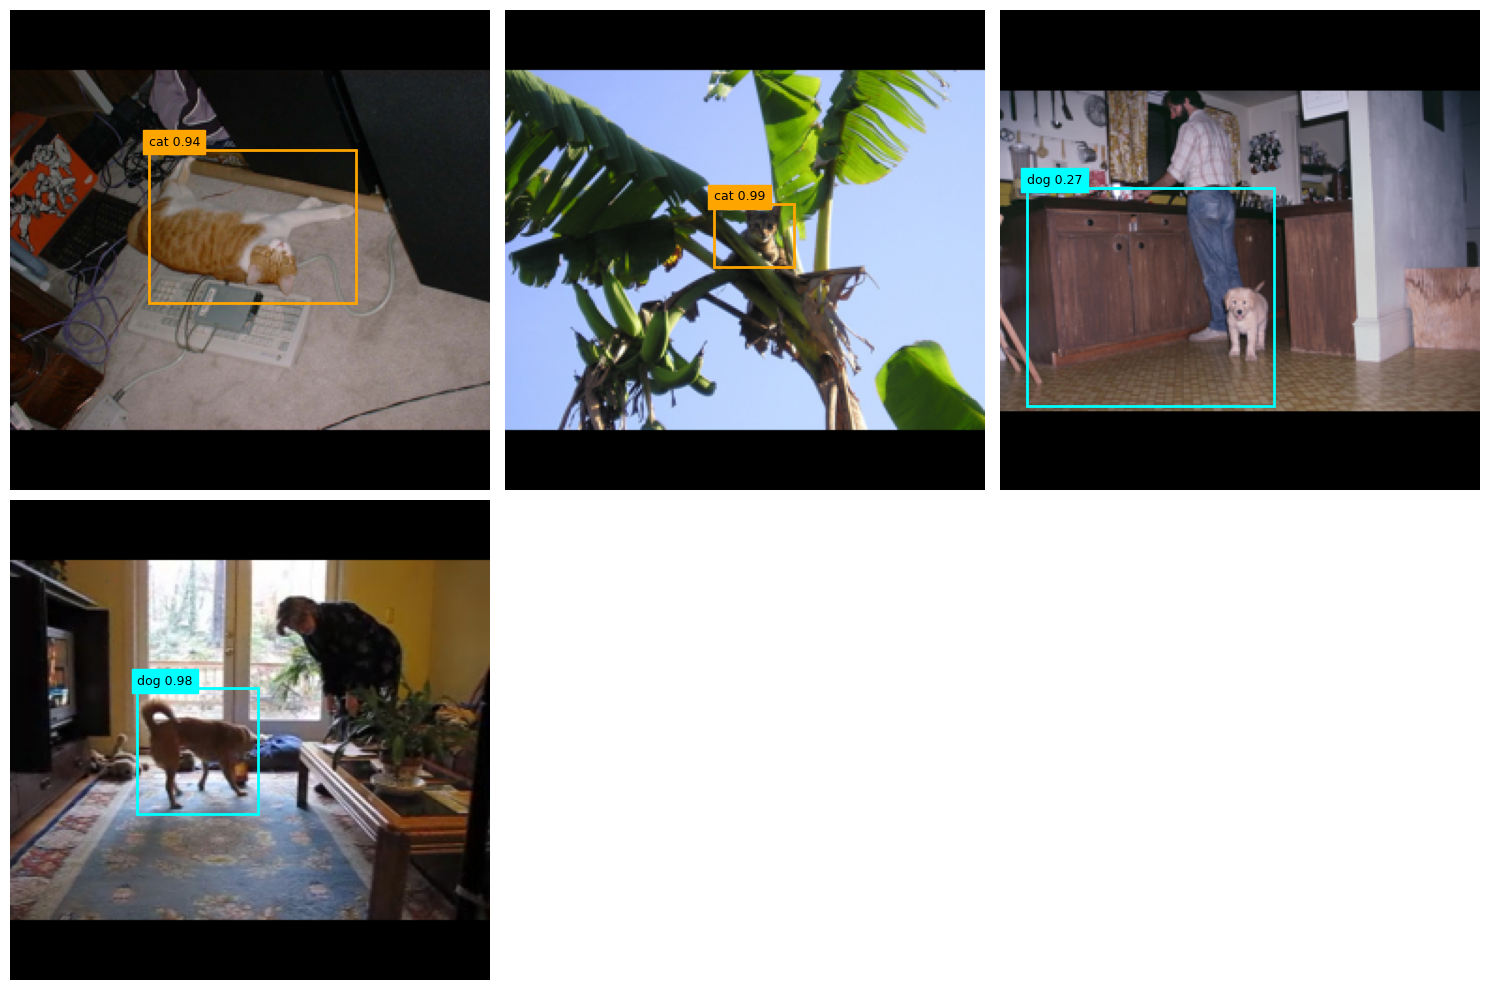

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.ops import nms
id_to_name = {v: k for k, v in seq_category_Ids.items()}
colors = {1: "orange", 2: "cyan", 3: "lime"}
def load_image(path, ImgDim):
    img = Image.open(path).convert("RGB")
    scale = ImgDim / max(img.height, img.width)
    new_h = round(img.height * scale)
    new_w = round(img.width * scale)
    img = np.array(img.resize((new_w, new_h)))
    pad_top = (ImgDim - new_h) - (ImgDim - new_h) // 2
    pad_left = (ImgDim - new_w) - (ImgDim - new_w) // 2
    img = np.pad(img, ((pad_top, (ImgDim - new_h) // 2), (pad_left, (ImgDim - new_w) // 2), (0, 0)), mode="constant")
    return torch.from_numpy(img).permute(2, 0, 1).contiguous()
test_imgs = []
for name in categories:
    candidates = coco.loadImgs(coco.getImgIds(catIds=[category_Ids[name]]))
    unseen = [info for info in candidates if info["id"] not in seen]
    test_imgs += unseen[:2]
batch = torch.stack([load_image(f"{dataDir}/images/{dataType}/{info['file_name']}", ImgDim) for info in test_imgs])
model.eval()
with torch.no_grad():
    cls_all, reg_all, obj_all = model.flatten_outputs(model.forward(batch.float().to(model.device)))
cls_prob = torch.sigmoid(cls_all[..., 1:]).cpu()
obj_prob = torch.sigmoid(obj_all).cpu()
reg_all = reg_all.cpu()
conf, cls_idx = (cls_prob * obj_prob).max(dim=-1)
cls_idx = cls_idx + 1
cols = 3
rows = math.ceil(len(batch) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)
for i, ax in enumerate(axes[:len(batch)]):
    ax.imshow(batch[i].permute(1, 2, 0).numpy())
    xyxy = reg_all[i].clone()
    xyxy[:, 2:] = xyxy[:, :2] + xyxy[:, 2:]
    xyxy = xyxy.clamp(0, ImgDim)
    top = conf[i].topk(200).indices
    sel = top[nms(xyxy[top], conf[i][top], 0.3)]
    sel = sel[conf[i][sel] >= 0.5 * conf[i][sel][0]][:5]
    for j in sel:
        x0, y0, x1, y1 = xyxy[j].tolist()
        c = int(cls_idx[i][j])
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=colors[c], linewidth=2))
        ax.text(x0, max(y0 - 2, 8), f"{id_to_name[c]} {float(conf[i][j]):.2f}", color="black", fontsize=9, backgroundcolor=colors[c])
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()